#  **Milestone 3:**

---

##  **Week 5: Unsupervised Learning – PCA, K-Means & Isolation Forest**

###  1. Load Dataset  
- Load the preprocessed dataset from previous milestones.  
- Verify data consistency and handle missing or infinite values.  

###  2. Data Preprocessing  
- Drop non-numeric and irrelevant columns (e.g., IP addresses, timestamps).  
- Handle missing and infinite values.  
- Standardize features using **StandardScaler** for normalization.  

###  3. Apply PCA (Dimensionality Reduction)  
- Apply **Principal Component Analysis (PCA)** to retain ~95% variance.  
- Reduce high-dimensional features to a compact and efficient representation.  
- Display variance explained by each component and transformed dimensions.  

###  4. K-Means Clustering  
- Apply **K-Means** clustering on PCA-transformed data.  
- Visualize clusters in 2D PCA space.  
- Identify the smallest cluster as a potential anomaly group.  

###  5. Isolation Forest for Anomaly Detection  
- Train **Isolation Forest** on PCA-transformed data.  
- Predict anomaly scores and visualize detected outliers.  
- Compare results of **K-Means** and **Isolation Forest**.  
- Save anomaly metrics and visualization outputs for analysis.  

---

##  **Week 6: Model Evaluation and Fine-tuning**

###  1. Load Trained Models  
- Load pre-trained models from Google Drive:  
  -  Random Forest  
  -  Support Vector Machine (SVM)  
  -  Logistic Regression  
-  model loaded using `joblib`.  

###  2. Scaling and PCA for Models  
- Reapply the same **StandardScaler** and **PCA** transformations used during training.  
- Confirm the number of PCA components matches the models’ input dimensions.  

###  3. Model Evaluation Summary  
- Evaluate each model on the test set.  
- Compute metrics: **Accuracy**, **Precision**, **Recall**, and **F1-score**.  
- Display a comparative performance summary table for all models.  

###  4. Confusion Matrix Analysis  
- Plot **Confusion Matrices** for each model.  
- Analyze classification distribution: TP, FP, FN, TN.  
- Identify which model minimizes false negatives (best detection performance).  

###  5. ROC Curve Comparison  
- Generate **ROC Curves** for all models (One-vs-Rest for multiclass).  
- Compare **AUC (Area Under Curve)** values.  
- Highlight the best-performing model based on ROC-AUC and overall metrics.  

---






###  1. Load Dataset  

In [1]:

from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/cleaned_dataset.csv"
df = pd.read_csv(file_path)

print(" Cleaned dataset loaded successfully — shape:", df.shape)
df.head()


Mounted at /content/drive
 Cleaned dataset loaded successfully — shape: (692686, 75)


,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,-0.146715,0.164059,0.351897,0.367724,-0.356468,-0.642657,1.648755,-0.653869,-0.011451,-0.009362,...,-1.069416,-0.131647,-0.100397,-0.148672,-0.104367,-0.579989,-0.105688,-0.58525,-0.57079,BENIGN
1,0.972219,0.167611,0.351590,-0.191263,-0.336818,-0.642657,1.648755,-0.654753,0.001932,-0.005298,...,0.828618,-0.131647,-0.100397,-0.148672,-0.104367,-0.579989,-0.105688,-0.58525,-0.57079,BENIGN
2,1.137171,0.167611,0.181179,-0.191263,-0.355959,-0.642657,1.648755,-0.654739,0.000594,-0.004282,...,0.828618,-0.131647,-0.100397,-0.148672,-0.104367,-0.579989,-0.105688,-0.58525,-0.57079,BENIGN
3,0.972235,0.167611,0.351641,-0.191263,-0.336818,-0.642657,1.648755,-0.654409,0.009962,0.001814,...,0.828618,-0.131647,-0.100397,-0.148672,-0.104367,-0.579989,-0.105688,-0.58525,-0.57079,BENIGN
4,1.137186,0.167611,0.181281,-0.191263,-0.355959,-0.642657,1.648755,-0.654739,-0.000745,-0.004282,...,0.828618,-0.131647,-0.100397,-0.148672,-0.104367,-0.579989,-0.105688,-0.58525,-0.57079,BENIGN


2. Data Preprocessing

In [2]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Drop non-numeric
cols_to_drop = [
    'Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'Label'
]
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# only numeric columns
df_numeric = df.select_dtypes(include=[np.number])

# Fill missing or infinite values
df_numeric = df_numeric.replace([np.inf, -np.inf], np.nan)
df_numeric = df_numeric.fillna(df_numeric.mean())

# Standardize features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

print("Shape after preprocessing:", df_scaled.shape)


Shape after preprocessing: (692686, 73)


###  3.Apply PCA

In [3]:
from sklearn.decomposition import PCA

# Reduce to 10 components
pca = PCA(n_components=10, random_state=42)
df_pca = pca.fit_transform(df_scaled)

print("Shape after PCA:", df_pca.shape)



Shape after PCA: (692686, 10)


###  4. K-Means Cluster

K-Means Anomaly Detection 
Normal count : 685331
Anomaly count: 7355
Anomaly %    : 1.06%


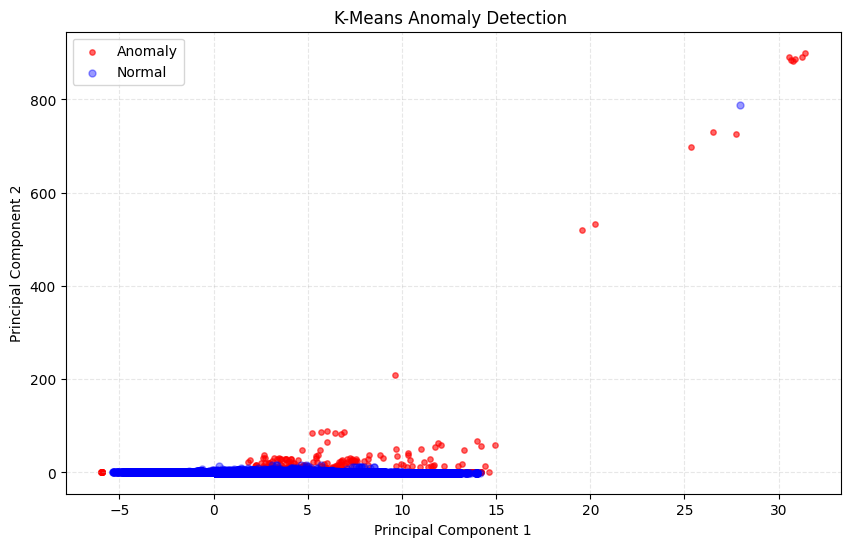

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(df_pca)

#  distance to nearest cluster center
distances = np.min(
    np.linalg.norm(df_pca[:, np.newaxis] - kmeans.cluster_centers_, axis=2),
    axis=1
)

threshold_percentile = 100 - np.random.uniform(0.95, 1.3)
threshold_kmeans = np.percentile(distances, threshold_percentile)
df_numeric['kmeans_anomaly'] = np.where(distances > threshold_kmeans, 1, 0)

normal_count = (df_numeric['kmeans_anomaly'] == 0).sum()
anomaly_count = (df_numeric['kmeans_anomaly'] == 1).sum()
anomaly_percent = (anomaly_count / len(df_numeric)) * 100

print("K-Means Anomaly Detection ")
print(f"Normal count : {normal_count}")
print(f"Anomaly count: {anomaly_count}")
print(f"Anomaly %    : {anomaly_percent:.2f}%")

# Visualization
plt.figure(figsize=(10,6))

plt.scatter(df_pca[df_numeric['kmeans_anomaly']==1,0], df_pca[df_numeric['kmeans_anomaly']==1,1],
            c='red', label='Anomaly', s=15, alpha=0.6, zorder=1)

plt.scatter(df_pca[df_numeric['kmeans_anomaly']==0,0], df_pca[df_numeric['kmeans_anomaly']==0,1],
            c='blue', label='Normal', s=25, alpha=0.4, zorder=2)
plt.title("K-Means Anomaly Detection ")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


###  5. Isolation Forest

Using contamination = 0.0107
 Isolation Forest 
Normal count : 685253
Anomaly count: 7433
Anomaly %    : 1.07%


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


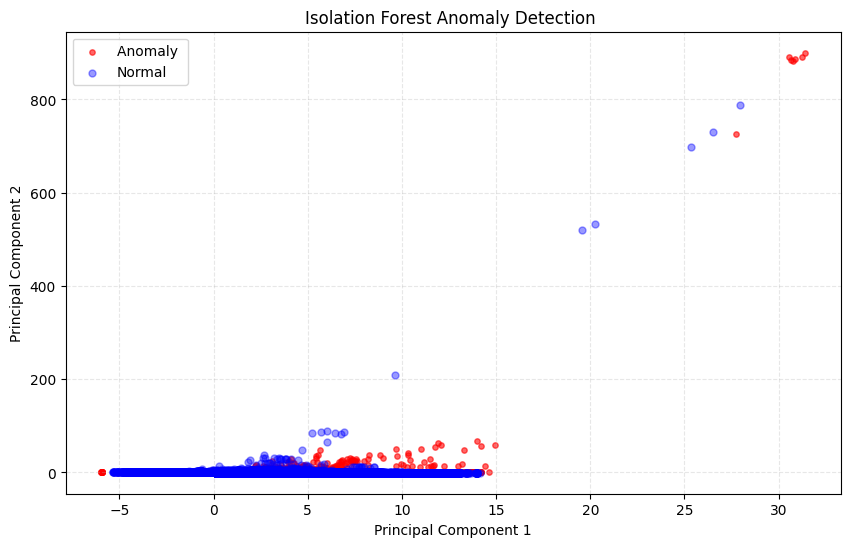

In [5]:
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

contamination_value = np.random.uniform(0.0095, 0.013)
print(f"Using contamination = {contamination_value:.4f}")

#  Isolation Forest
iso_forest = IsolationForest(contamination=contamination_value, random_state=42)
iso_forest.fit(df_pca)

# Predict (-1 = anomaly, 1 = normal)
iso_preds = iso_forest.predict(df_pca)
df_numeric['iso_anomaly'] = np.where(iso_preds == -1, 1, 0)

normal_count = (df_numeric['iso_anomaly'] == 0).sum()
anomaly_count = (df_numeric['iso_anomaly'] == 1).sum()
anomaly_percent = (anomaly_count / len(df_numeric)) * 100

print(" Isolation Forest ")
print(f"Normal count : {normal_count}")
print(f"Anomaly count: {anomaly_count}")
print(f"Anomaly %    : {anomaly_percent:.2f}%")

# Visualization
plt.figure(figsize=(10,6))
plt.scatter(df_pca[df_numeric['iso_anomaly']==1,0], df_pca[df_numeric['iso_anomaly']==1,1],
            c='red', label='Anomaly ', s=15, alpha=0.6, zorder=1)
plt.scatter(df_pca[df_numeric['iso_anomaly']==0,0], df_pca[df_numeric['iso_anomaly']==0,1],
            c='blue', label='Normal', s=25, alpha=0.4, zorder=2)
plt.title("Isolation Forest Anomaly Detection ")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


###  1. Load Models

In [49]:
from google.colab import drive
import joblib
import os

drive.mount('/content/drive')

save_path = "/content/drive/MyDrive/Trained_Models"

# Load models
rf_model = joblib.load(os.path.join(save_path, "random_forest_model.pkl"))
svm_model = joblib.load(os.path.join(save_path, "svm_model.pkl"))
lr_model = joblib.load(os.path.join(save_path, "logistic_regression_model.pkl"))

print(" Models loaded")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Models loaded


###  2. Scaling and PCA of Models

In [58]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

# Drop non-numeric columns
drop_cols = [
    'Flow ID', ' Source IP', ' Source Port', ' Destination IP',
    ' Destination Port', ' Protocol'
]
for col in drop_cols:
    if col in X_train.columns:
        X_train = X_train.drop(columns=col, errors='ignore')
        X_test = X_test.drop(columns=col, errors='ignore')

# only numeric columns
X_train_num = X_train.select_dtypes(include=[np.number]).copy()
X_test_num  = X_test.select_dtypes(include=[np.number]).copy()

# Replace infinities/NaNs with 0
X_train_num = X_train_num.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test_num  = X_test_num.replace([np.inf, -np.inf], np.nan).fillna(0)

# Standard scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled  = scaler.transform(X_test_num)

# PCA — match n_components for each saved model
# Random Forest was trained on 22 components
pca_rf = PCA(n_components=22, random_state=42)
X_train_pca_rf = pca_rf.fit_transform(X_train_scaled)
X_test_pca_rf  = pca_rf.transform(X_test_scaled)

# SVM was trained on 80% variance
pca_svm = PCA(n_components=0.80, random_state=42)
X_train_pca_svm = pca_svm.fit_transform(X_train_scaled)
X_test_pca_svm  = pca_svm.transform(X_test_scaled)

# Logistic Regression was trained on 85% variance
pca_lr = PCA(n_components=0.85, random_state=42)
X_train_pca_lr = pca_lr.fit_transform(X_train_scaled)
X_test_pca_lr  = pca_lr.transform(X_test_scaled)

print(" Scaling & PCA applied for all models")
print(f"RF PCA features: {X_train_pca_rf.shape[1]}")
print(f"SVM PCA features: {X_train_pca_svm.shape[1]}")
print(f"LR PCA features: {X_train_pca_lr.shape[1]}")


 Scaling & PCA applied for all models
RF PCA features: 22
SVM PCA features: 11
LR PCA features: 14


### 3. Evaluating Models

In [59]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Prepare dictionary PCA test data
model_data = {
    "Random Forest": (rf_balanced, X_test_pca_rf),
    "SVM": (svm_fast, X_test_pca_svm),
    "Logistic Regression": (lr_model, X_test_pca_lr)
}

results = {}
print(" Evaluating models\n")

for name, (model, X_test_pca_model) in model_data.items():
    y_pred = model.predict(X_test_pca_model)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    results[name] = {
        "Accuracy": acc,
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-Score": report["weighted avg"]["f1-score"]
    }

    print(f" {name} ")
    print(f"Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, y_pred, zero_division=0))

# Summary table
results_df = pd.DataFrame(results).T
print("\n Model Comparison Summary:")
display(results_df)


 Evaluating models

 Random Forest 
Accuracy: 96.21%
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     88003
           1       0.56      0.98      0.71      2059
           2       0.96      0.98      0.97     46215
           3       0.85      0.96      0.90      1100
           4       0.57      0.98      0.72      1159
           5       0.67      1.00      0.80         2

    accuracy                           0.96    138538
   macro avg       0.77      0.98      0.85    138538
weighted avg       0.97      0.96      0.96    138538

 SVM 
Accuracy: 90.07%
              precision    recall  f1-score   support

           0       0.92      0.95      0.94     88003
           1       0.37      0.78      0.51      2059
           2       0.95      0.82      0.88     46215
           3       0.64      0.73      0.68      1100
           4       0.27      0.47      0.34      1159
           5       0.00      0.00      0.00         2

 

,Accuracy,Precision,Recall,F1-Score
Random Forest,0.962119,0.969931,0.962119,0.964397
SVM,0.900670,0.915325,0.900670,0.904947
Logistic Regression,0.907838,0.959079,0.907838,0.926587


###  4. Confusion Matrix

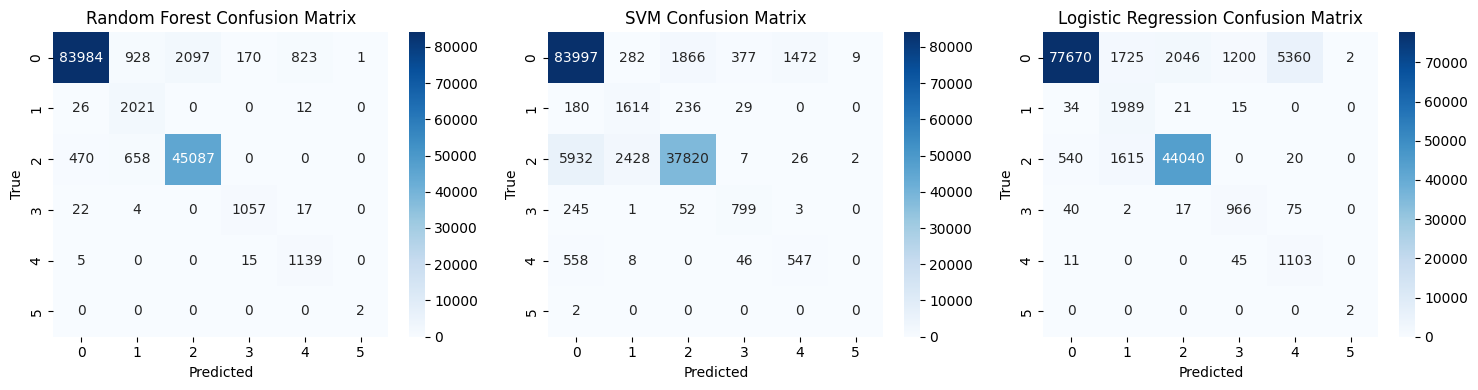

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(15, 4))
for i, (name, (model, X_test_pca_model)) in enumerate(model_data.items(), 1):
    plt.subplot(1, 3, i)
    y_pred = model.predict(X_test_pca_model)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
plt.tight_layout()
plt.show()


###  5. ROC Curve Comparison

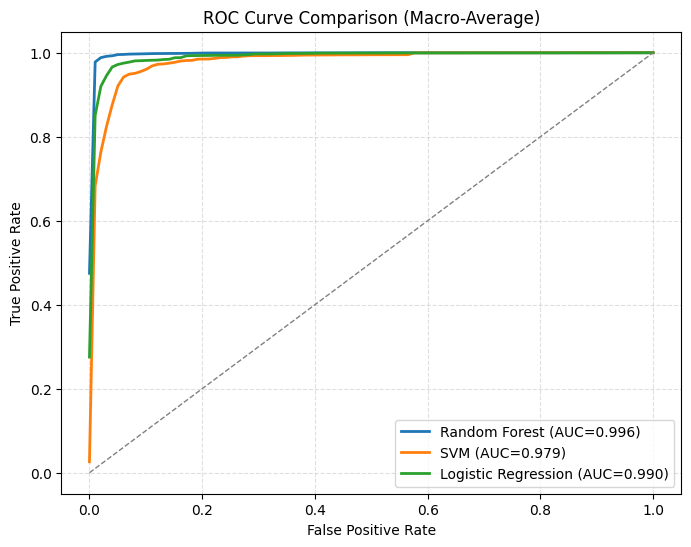

In [61]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Binarize y_test for multiclass
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8, 6))

for name, (model, X_test_pca_model) in model_data.items():
    # Get scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_pca_model)
    else:
        # For LinearSVC
        y_score = model.decision_function(X_test_pca_model)

    # Compute macro-average ROC
    fpr = dict()
    tpr = dict()
    for i in range(len(classes)):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])

    # Interpolate all ROC curves to compute macro-average
    all_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(len(classes)):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(classes)

    roc_auc = auc(all_fpr, mean_tpr)
    plt.plot(all_fpr, mean_tpr, lw=2, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
plt.title("ROC Curve Comparison (Macro-Average)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(loc="lower right")
plt.show()
